In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cyclomatic_complexity import calculate_cyclomatic_complexity
from lib.utils.file_io import read_complexity_jsonl

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams.update(font_setting.fig_setting)
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'   # 그리스 지원

import statsmodels.formula.api as smf
from scipy import stats

from scipy.stats import linregress, ttest_1samp

from statsmodels.stats.multitest import multipletests






In [2]:
run_id_start = 20000

tot_viz_df = pd.DataFrame()
# for idx, lang in enumerate(list({lang: set_ for lang, set_ in CONSTANTS.LANG_INFO.items() if set_[1] is not None}.keys())):
lang = 'python'
idx = 0

print(f'[visualizing....] start visualizing {lang} language')
output_dir = create_dir('./fig/')
src_dir = f'{path_list["data_root_dir"]}/result/code_complexity/cyclomatic_complexity/run_id_{run_id_start+idx}'
option_dict = load_json(f"{src_dir}/data/option.json")
std_date = Date_Setting[option_dict['year_range']]['std_date']

origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])
df = read_complexity_jsonl(option_dict)
viz_df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'cyclomatic_complexity', 'nloc']]
viz_df['language'] = lang
tot_viz_df = pd.concat([tot_viz_df, viz_df], ignore_index=True)




[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:12<00:00,  5.09it/s]


In [6]:
origin_df.to_json(f'{path_list["data_root_dir"]}/result/code_complexity/cyclomatic_complexity/origin_df.json', orient='columns')

In [3]:


# ═══════════════════════════════════════════
# 0. 설정
# ═══════════════════════════════════════════
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'         # ⭐ 변수명 정직하게
BIN_SIZE     = 4
MIN_BIN      = -28
MAX_BIN      = +39
REF_BIN      = -1

MIN_LANGS_PER_BIN = 10
MIN_FUNC_PER_CELL = 50

# ═══════════════════════════════════════════
# 1. 데이터 준비
# ═══════════════════════════════════════════
df = tot_viz_df.copy()
df['creationdate'] = pd.to_datetime(df['creationdate'], format='mixed')
df = df[df['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()

df['log_cc'] = np.log1p(df['cyclomatic_complexity'])
df['week'] = np.floor((pd.to_datetime(df['creationdate'], format='mixed')- std_date).dt.days/7)
df['week'] = df['creationdate'].dt.to_period('W').dt.start_time

valid = df['language'].value_counts()[lambda s: s >= 1000].index
df = df[df['language'].isin(valid)].copy()

# 주별 × 언어별 집계
weekly_var = df.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),                       
    log_cc_std  = ('log_cc', 'std'),
    cc_mean_raw = ('cyclomatic_complexity', 'mean'),        # 비교용 (raw)
    cc_std_raw  = ('cyclomatic_complexity', 'std'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()

weekly_var = weekly_var[weekly_var['n_func'] >= 30].copy()
weekly_var['weeks_since'] = (weekly_var['week'] - CHATGPT_DATE).dt.days / 7

# Event time 빈
weekly_var['event_bin'] = (weekly_var['weeks_since'] // BIN_SIZE).astype(int)
weekly_var = weekly_var[
    (weekly_var['event_bin'] >= MIN_BIN) &
    (weekly_var['event_bin'] <= MAX_BIN)
].copy()

print(f"초기 데이터: {len(weekly_var):,}개 행, {weekly_var['language'].nunique()}개 언어")

# ⭐ log_cc_mean과 raw cc_mean 분포 비교 (확인용)
print(f"\n=== 종속변수 분포 비교 ===")
print(f"log_cc_mean: mean={weekly_var['log_cc_mean'].mean():.3f}, "
      f"std={weekly_var['log_cc_mean'].std():.3f}, "
      f"range=[{weekly_var['log_cc_mean'].min():.3f}, {weekly_var['log_cc_mean'].max():.3f}]")
print(f"cc_mean_raw: mean={weekly_var['cc_mean_raw'].mean():.3f}, "
      f"std={weekly_var['cc_mean_raw'].std():.3f}, "
      f"range=[{weekly_var['cc_mean_raw'].min():.3f}, {weekly_var['cc_mean_raw'].max():.3f}]")

초기 데이터: 3,365개 행, 19개 언어

=== 종속변수 분포 비교 ===
log_cc_mean: mean=0.945, std=0.114, range=[0.703, 1.506]
cc_mean_raw: mean=1.897, std=0.502, range=[1.024, 5.135]


In [4]:

# ═══════════════════════════════════════════
# 2. 진단
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("1단계: 데이터 진단")
print("="*60)

clean_data = weekly_var.dropna(subset=[TARGET])

bin_stats = clean_data.groupby('event_bin').agg(
    n_obs=(TARGET, 'count'),
    n_lang=('language', 'nunique'),
    total_func=('n_func', 'sum'),
).reset_index()
print(f"\n빈별 표본 분포:")
print(bin_stats.describe()[['n_obs', 'n_lang', 'total_func']].round(1))

pivot = clean_data.pivot_table(
    index='event_bin', columns='language',
    values=TARGET, aggfunc='count', fill_value=0,
)
n_empty = (pivot == 0).sum().sum()
n_total = pivot.size
print(f"\n빈×언어 매트릭스: {n_empty}/{n_total} 셀 비어 있음 ({n_empty/n_total*100:.1f}%)")

# ═══════════════════════════════════════════
# 3. 데이터 정제 (현재 비활성)
# ═══════════════════════════════════════════
weekly_clean = weekly_var.copy()



1단계: 데이터 진단

빈별 표본 분포:
       n_obs  n_lang  total_func
count   66.0    66.0        66.0
mean    51.0    14.2     29137.6
std     12.3     2.5     19558.3
min     13.0     6.0       629.0
25%     48.0    13.0     10606.5
50%     56.0    15.0     26200.5
75%     59.0    16.0     47149.5
max     64.0    18.0     61321.0

빈×언어 매트릭스: 316/1254 셀 비어 있음 (25.2%)



3단계: 통합 Event Study 회귀
log_cc_mean ~ C(event_bin, Treatment(reference=-1)) + C(language)
C(event_bin, Treatment(reference=-1))[T.-27]
C(event_bin, Treatment(reference=-1))[T.-26]
C(event_bin, Treatment(reference=-1))[T.-25]
C(event_bin, Treatment(reference=-1))[T.-24]
C(event_bin, Treatment(reference=-1))[T.-23]
C(event_bin, Treatment(reference=-1))[T.-22]
C(event_bin, Treatment(reference=-1))[T.-21]
C(event_bin, Treatment(reference=-1))[T.-20]
C(event_bin, Treatment(reference=-1))[T.-19]
C(event_bin, Treatment(reference=-1))[T.-18]
C(event_bin, Treatment(reference=-1))[T.-17]
C(event_bin, Treatment(reference=-1))[T.-16]
C(event_bin, Treatment(reference=-1))[T.-15]
C(event_bin, Treatment(reference=-1))[T.-14]
C(event_bin, Treatment(reference=-1))[T.-13]
C(event_bin, Treatment(reference=-1))[T.-12]
C(event_bin, Treatment(reference=-1))[T.-11]
C(event_bin, Treatment(reference=-1))[T.-10]
C(event_bin, Treatment(reference=-1))[T.-9]
C(event_bin, Treatment(reference=-1))[T.-8]
C(event_bin,

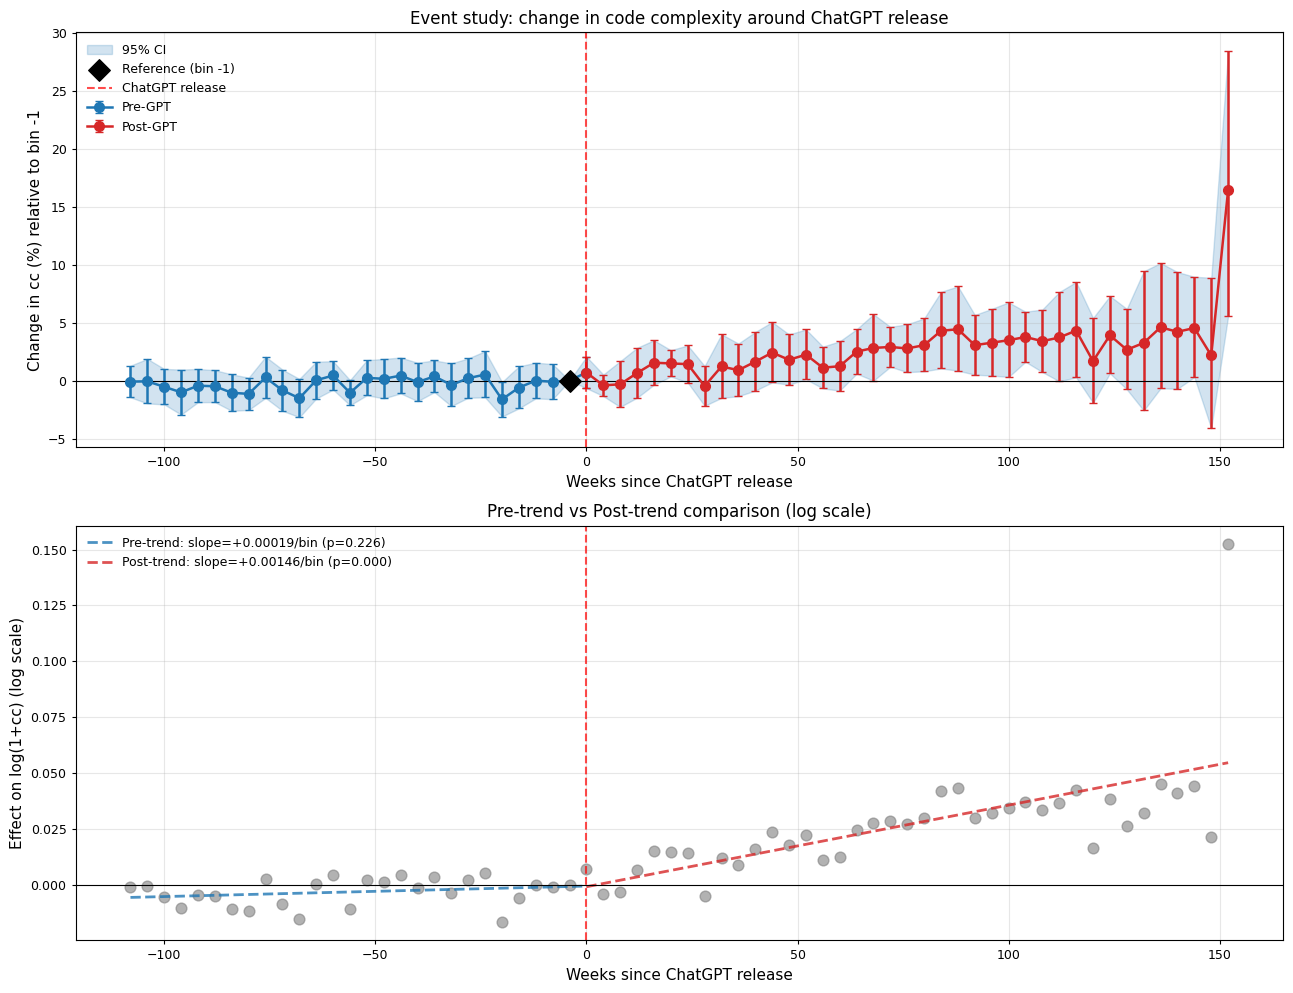

In [5]:

# ═══════════════════════════════════════════
# 4. 통합 Event Study 회귀
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("3단계: 통합 Event Study 회귀")
print("="*60)

formula_pool = (f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN}))'
                f' + C(language)')

m_pool = smf.wls(formula_pool, data=weekly_clean,
                ).fit(
    cov_type='cluster', cov_kwds={'groups': weekly_clean['language']},
)
print(formula_pool)

pool_results = []
for term in m_pool.params.index:
    if 'C(event_bin' not in term:
        continue
    bin_val = int(term.split('T.')[1].split(']')[0])
    print(term)
    pool_results.append({
        'event_bin': bin_val,
        'weeks':     bin_val * BIN_SIZE,
        'coef':      m_pool.params[term],
        'se':        m_pool.bse[term],
        'p_value':   m_pool.pvalues[term],
        'ci_low':    m_pool.params[term] - 1.96 * m_pool.bse[term],
        'ci_high':   m_pool.params[term] + 1.96 * m_pool.bse[term],
    })
pool_results.append({
    'event_bin': REF_BIN, 'weeks': REF_BIN * BIN_SIZE,
    'coef': 0, 'se': 0, 'p_value': 1, 'ci_low': 0, 'ci_high': 0,
})
pool_df = pd.DataFrame(pool_results).sort_values('event_bin').reset_index(drop=True)

# ⭐ % 단위 변환 추가 (log 회귀 → % 해석)
def beta_to_pct(beta):
    """log 회귀 계수 → % 변화"""
    return (np.exp(beta) - 1) * 100

pool_df['coef_pct']    = beta_to_pct(pool_df['coef'])
pool_df['ci_low_pct']  = beta_to_pct(pool_df['coef'] - 1.96 * pool_df['se'])
pool_df['ci_high_pct'] = beta_to_pct(pool_df['coef'] + 1.96 * pool_df['se'])

# ═══════════════════════════════════════════
# 5. Pre-trends 검정
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("4단계: Pre-trends 검정")
print("="*60)

pre_data = pool_df[pool_df['event_bin'] < 0].copy()

if len(pre_data) > 3:
    res = linregress(pre_data['event_bin'], pre_data['coef'])
    print(f"\n[선형 추세 검정]")
    print(f"  Slope: {res.slope:+.5f}/bin (p={res.pvalue:.4f})")
    print(f"  R²:    {res.rvalue**2:.4f}")
    if res.pvalue > 0.05:
        print("  ✅ Pre-trends 추세 없음 (DiD 가정 충족)")
    else:
        print("  ⚠️ Pre-trends에 추세 있음")

if len(pre_data) > 0:
    t, p = ttest_1samp(pre_data['coef'], 0)
    print(f"\n[Pre-bins 평균 = 0 검정]")
    print(f"  평균 효과: {pre_data['coef'].mean():+.5f} (= {beta_to_pct(pre_data['coef'].mean()):+.2f}%)")
    print(f"  t={t:.3f}, p={p:.4f}")

if len(pre_data) > 1:
    pre_with_p = pre_data[pre_data['p_value'] < 1].copy()
    if len(pre_with_p) > 0:
        _, pre_p_adj, _, _ = multipletests(pre_with_p['p_value'].values, method='bonferroni')
        n_sig = (pre_p_adj < 0.05).sum()
        print(f"\n[개별 pre-bin 검정, Bonferroni 보정]")
        print(f"  유의한 pre-bin: {n_sig}/{len(pre_with_p)}")

# ═══════════════════════════════════════════
# 6. 처치 후 효과 요약 (% 단위 추가)
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("5단계: 처치 후 효과 요약")
print("="*60)

post_data = pool_df[pool_df['event_bin'] > 0]
print(f"\n[처치 후 빈 효과] (log 단위 → % 변환)")
print(f"  평균 효과:      {post_data['coef'].mean():+.5f} "
      f"(= {beta_to_pct(post_data['coef'].mean()):+.2f}%)")
print(f"  중앙값 효과:    {post_data['coef'].median():+.5f} "
      f"(= {beta_to_pct(post_data['coef'].median()):+.2f}%)")
print(f"  유의한 빈 수:   {(post_data['p_value'] < 0.05).sum()}/{len(post_data)}")
print(f"  양수 빈 수:     {(post_data['coef'] > 0).sum()}/{len(post_data)}")

if len(post_data) > 3:
    res_post = linregress(post_data['event_bin'], post_data['coef'])
    print(f"\n[처치 후 추세]")
    print(f"  Slope: {res_post.slope:+.5f}/bin (p={res_post.pvalue:.4f})")
    print(f"  → 처치 후 효과가 시간 지나며 {'증가' if res_post.slope > 0 else '감소'}")

# 누적 효과 (마지막 빈)
final_β = post_data['coef'].iloc[-1]
final_pct = beta_to_pct(final_β)
final_week = post_data['weeks'].iloc[-1]
print(f"\n[누적 효과 (최종 시점)]")
print(f"  {final_week}주 시점: β={final_β:+.4f} → {final_pct:+.2f}%")

# ═══════════════════════════════════════════
# 7. 시각화 — % 단위로 표시
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# (1) 메인 Event Study Plot
ax = axes[0]

# 신뢰구간 (% 단위)
ax.fill_between(pool_df['weeks'], pool_df['ci_low_pct'], pool_df['ci_high_pct'],
                alpha=0.2, color='C0', label='95% CI')

pre  = pool_df[pool_df['event_bin'] <= 0]
post = pool_df[pool_df['event_bin'] >= 0]

# Errorbar도 % 단위
ax.errorbar(pre['weeks'], pre['coef_pct'], 
            yerr=[pre['coef_pct']-pre['ci_low_pct'], pre['ci_high_pct']-pre['coef_pct']],
            fmt='o-', markersize=7, capsize=3, lw=1.8, color='C0', label='Pre-GPT')
ax.errorbar(post['weeks'], post['coef_pct'],
            yerr=[post['coef_pct']-post['ci_low_pct'], post['ci_high_pct']-post['coef_pct']],
            fmt='o-', markersize=7, capsize=3, lw=1.8, color='C3', label='Post-GPT')

ax.scatter([REF_BIN * BIN_SIZE], [0], color='black', s=120, 
           zorder=5, marker='D', label=f'Reference (bin {REF_BIN})')

ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='red', ls='--', alpha=0.7, label='ChatGPT release')

ax.set_xlabel('Weeks since ChatGPT release', fontsize=11)
ax.set_ylabel(f'Change in cc (%) relative to bin {REF_BIN}', fontsize=11)   # ⭐ % 라벨
ax.set_title(f'Event study: change in code complexity around ChatGPT release', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

# (2) Pre/Post 추세선 시각화 (log 단위 그대로)
ax = axes[1]

ax.scatter(pool_df['weeks'], pool_df['coef'], 
           s=60, alpha=0.6, color='gray')

if len(pre_data) > 3:
    x_pre = np.linspace(pre_data['weeks'].min(), 0, 50)
    y_pre = res.intercept + res.slope * (x_pre / BIN_SIZE)
    ax.plot(x_pre, y_pre, 'C0--', lw=2, alpha=0.8,
            label=f'Pre-trend: slope={res.slope:+.5f}/bin (p={res.pvalue:.3f})')

if len(post_data) > 3:
    x_post = np.linspace(0, post_data['weeks'].max(), 50)
    y_post = res_post.intercept + res_post.slope * (x_post / BIN_SIZE)
    ax.plot(x_post, y_post, 'C3--', lw=2, alpha=0.8,
            label=f'Post-trend: slope={res_post.slope:+.5f}/bin (p={res_post.pvalue:.3f})')

ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='red', ls='--', alpha=0.7)

ax.set_xlabel('Weeks since ChatGPT release', fontsize=11)
ax.set_ylabel(f'Effect on log(1+cc) (log scale)', fontsize=11)
ax.set_title('Pre-trend vs Post-trend comparison (log scale)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('event_study_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
m_pool.summary()

/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 83, but rank is 18
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:            log_cc_mean   R-squared:                       0.801
Model:                            WLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                 4.582e+11
Date:                Sun, 17 May 2026   Prob (F-statistic):          2.73e-101
Time:                        22:28:05   Log-Likelihood:                 5259.9
No. Observations:                3365   AIC:                        -1.035e+04
Df Residuals:                    3281   BIC:                            -9838.
Df Model:                          83                                         
Covariance Type:              cluster                                         
================================================================================================================
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                        1.2165      0.008    151.537      0.000       1.201       1.232
C(event_bin, Treatment(reference=-1))[T.-27]    -0.0008      0.007     -0.121      0.903      -0.015       0.013
C(event_bin, Treatment(reference=-1))[T.-26]    -0.0006      0.010     -0.063      0.949      -0.020       0.019
C(event_bin, Treatment(reference=-1))[T.-25]    -0.0054      0.008     -0.683      0.495      -0.021       0.010
C(event_bin, Treatment(reference=-1))[T.-24]    -0.0101      0.010     -1.012      0.312      -0.030       0.009
C(event_bin, Treatment(reference=-1))[T.-23]    -0.0044      0.007     -0.598      0.550      -0.019       0.010
C(event_bin, Treatment(reference=-1))[T.-22]    -0.0049      0.007     -0.689      0.491      -0.019       0.009
C(event_bin, Treatment(reference=-1))[T.-21]    -0.0106      0.008     -1.299      0.194      -0.026       0.005
C(event_bin, Treatment(reference=-1))[T.-20]    -0.0115      0.007     -1.602      0.109      -0.026       0.003
C(event_bin, Treatment(reference=-1))[T.-19]     0.0027      0.009      0.298      0.765      -0.015       0.020
C(event_bin, Treatment(reference=-1))[T.-18]    -0.0084      0.009     -0.922      0.357      -0.026       0.009
C(event_bin, Treatment(reference=-1))[T.-17]    -0.0153      0.009     -1.787      0.074      -0.032       0.001
C(event_bin, Treatment(reference=-1))[T.-16]     0.0003      0.008      0.041      0.967      -0.016       0.016
C(event_bin, Treatment(reference=-1))[T.-15]     0.0044      0.006      0.710      0.478      -0.008       0.017
C(event_bin, Treatment(reference=-1))[T.-14]    -0.0106      0.006     -1.891      0.059      -0.022       0.000
C(event_bin, Treatment(reference=-1))[T.-13]     0.0024      0.008      0.313      0.754      -0.013       0.018
C(event_bin, Treatment(reference=-1))[T.-12]     0.0016      0.009      0.179      0.858      -0.015       0.019
C(event_bin, Treatment(reference=-1))[T.-11]     0.0043      0.008      0.551      0.582      -0.011       0.020
C(event_bin, Treatment(reference=-1))[T.-10]    -0.0013      0.008     -0.152      0.879      -0.018       0.015
C(event_bin, Treatment(reference=-1))[T.-9]      0.0037      0.007      0.526      0.599      -0.010       0.017
C(event_bin, Treatment(reference=-1))[T.-8]     -0.0038      0.009     -0.399      0.690      -0.022       0.015
C(event_bin, Treatment(reference=-1))[T.-7]      0.0021      0.009      0.242      0.809      -0.015       0.019
C(event_bin, Treatment(reference=-1))[T.-6]      0.0052      0.010      0.518      0.604      -0.015       0.025
C(event_bin, Treatment(reference=-1))[T.-5]     -0.0164      0.008     -2.118      0.034      -0.032      -0.001
C(event_bin, Treatment(reference

시각화용 데이터 범위: -108 ~ 152 weeks
점 개수: 66


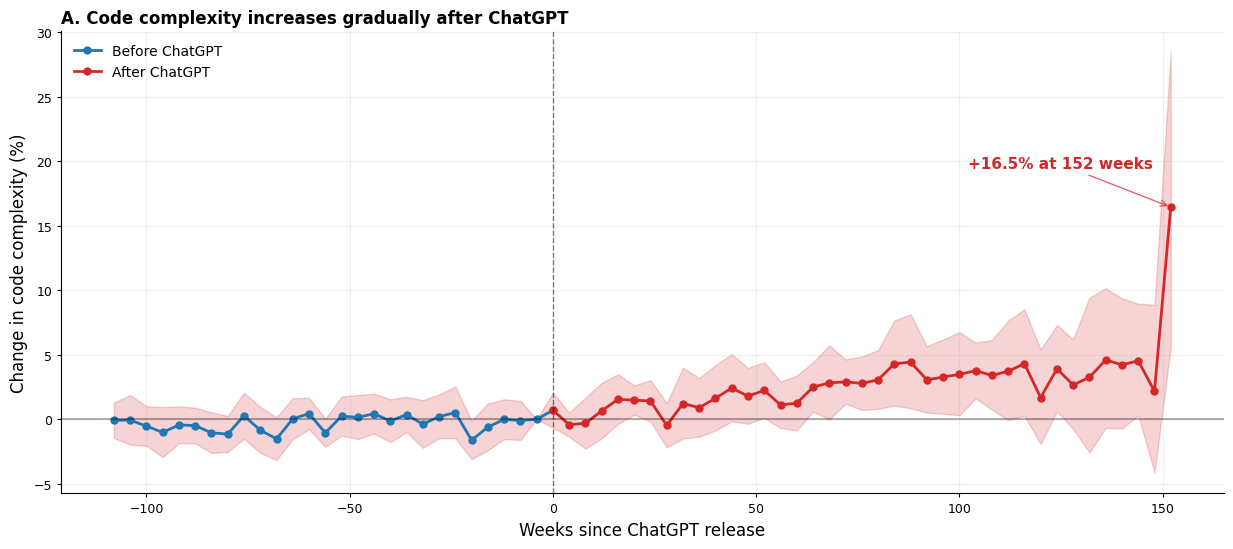

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ───────────────────────────────────────────
# % 변환 함수 (log 회귀용)
# ───────────────────────────────────────────
def beta_to_pct(beta):
    """log 회귀 계수 → % 변화"""
    return (np.exp(beta) - 1) * 100

# ───────────────────────────────────────────
# 사전 준비
# ───────────────────────────────────────────
BIN_SIZE = 4

# pool_df는 이미 coef, se 등을 가지고 있음 (log 단위)
agg = pool_df.copy()
agg['weeks'] = agg['event_bin'] * BIN_SIZE

# ⭐ % 변환 (log 회귀이므로 exp 변환)
agg['coef_pct']    = beta_to_pct(agg['coef'])
agg['ci_low_pct']  = beta_to_pct(agg['coef'] - 1.96 * agg['se'])
agg['ci_high_pct'] = beta_to_pct(agg['coef'] + 1.96 * agg['se'])

print(f"시각화용 데이터 범위: {agg['weeks'].min()} ~ {agg['weeks'].max()} weeks")
print(f"점 개수: {len(agg)}")


# ═══════════════════════════════════════════
# 메인 그림
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(15, 6))

# ───────────────────────────────────────────
# Panel A: Event study
# ───────────────────────────────────────────

# 신뢰밴드
ax.fill_between(agg['weeks'], agg['ci_low_pct'], agg['ci_high_pct'],
                alpha=0.2, color='#d62728')

# 처치 전후 색깔
pre  = agg[agg['weeks'] <= 0].sort_values('weeks')
post = agg[agg['weeks'] >= 0].sort_values('weeks')

ax.plot(pre['weeks'],  pre['coef_pct'], 'o-', color='#1f77b4',
        lw=2, markersize=5, label='Before ChatGPT')
ax.plot(post['weeks'], post['coef_pct'], 'o-', color='#d62728',
        lw=2, markersize=5, label='After ChatGPT')

ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1)
ax.axhline(0, color='black', alpha=0.3)

# 누적 효과 표시
final_pct  = post['coef_pct'].iloc[-1]
final_week = post['weeks'].iloc[-1]

ax.annotate(f'+{final_pct:.1f}% at {final_week:.0f} weeks',
            xy=(final_week, final_pct),
            xytext=(final_week - 50, final_pct + 3),
            fontsize=11, fontweight='bold', color='#d62728',
            arrowprops=dict(arrowstyle='->', color='#d62728', alpha=0.7))

ax.set_xlabel('Weeks since ChatGPT release', fontsize=12)
ax.set_ylabel('Change in code complexity (%)', fontsize=12)
ax.set_title('A. Code complexity increases gradually after ChatGPT',
             fontsize=12, fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


In [8]:
# ───── 설정 ─────
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'
MIN_WEEK     = -112
MAX_WEEK     = +160
 
# ═══════════════════════════════════════════
# 1. 데이터 준비
# ═══════════════════════════════════════════
df = tot_viz_df.copy()
df['creationdate'] = pd.to_datetime(df['creationdate'], format='mixed')
df = df[df['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()
df['log_cc'] = np.log1p(df['cyclomatic_complexity'])
df['week'] = df['creationdate'].dt.to_period('W').dt.start_time
 
valid = df['language'].value_counts()[lambda s: s >= 1000].index
df = df[df['language'].isin(valid)].copy()
 
weekly = df.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()
 
weekly = weekly[weekly['n_func'] >= 30].copy()
weekly['weeks_since'] = ((weekly['week'] - CHATGPT_DATE).dt.days / 7).round().astype(int)
weekly = weekly[(weekly['weeks_since'] >= MIN_WEEK) &
                (weekly['weeks_since'] <= MAX_WEEK)].copy()
 
# ITS 핵심 변수
weekly['t']      = weekly['weeks_since']
weekly['post']   = (weekly['weeks_since'] >= 0).astype(int)
weekly['post_t'] = weekly['post'] * weekly['weeks_since']
 
print(f"n = {len(weekly):,}, 언어 = {weekly['language'].nunique()}")
print(f"기간: {weekly['weeks_since'].min()} ~ {weekly['weeks_since'].max()}주")
 
# ═══════════════════════════════════════════
# 2. Pooled ITS 회귀 (HAC SE)
# ═══════════════════════════════════════════
weekly = weekly.sort_values(['language', 't']).reset_index(drop=True)
 
formula = f'{TARGET} ~ t + post + post_t + C(language)'
print(formula)
m = smf.wls(formula, data=weekly).fit(
    cov_type='cluster', cov_kwds={'groups': weekly_clean['language']},
)

 
# ───── 결과 출력 ─────
print("\n" + "="*60)
print("Pooled ITS 결과 (HAC SE)")
print("="*60)
 
def pct(b): return (np.exp(b) - 1) * 100
 
for term, label in [('t',      'Pre-trend     (기준선 기울기)'),
                    ('post',   'Level change  (즉각 수준 변화)'),
                    ('post_t', 'Slope change  (추세 기울기 변화)')]:
    β, se, p = m.params[term], m.bse[term], m.pvalues[term]
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    print(f"  {label}: β={β:+.5f} (SE={se:.5f}, p={p:.4f}) {sig}  → {pct(β):+.3f}%")
 
print(f"\nR² = {m.rsquared:.4f}, n = {int(m.nobs):,}")
 
# ═══════════════════════════════════════════
# 3. 시점별 효과 + 95% CI (Delta method)
# ═══════════════════════════════════════════
def its_effect(model, t_grid):
    """ITS 효과 = β_post + β_post_t × t, 시점별 SE는 delta method"""
    β_p, β_pt = model.params['post'], model.params['post_t']
    cov = model.cov_params()
    v_p, v_pt = cov.loc['post','post'], cov.loc['post_t','post_t']
    c_p_pt    = cov.loc['post','post_t']
 
    eff = np.where(t_grid >= 0, β_p + β_pt * t_grid, 0.0)
    var = np.where(t_grid >= 0,
                   v_p + (t_grid**2)*v_pt + 2*t_grid*c_p_pt, 0.0)
    se  = np.sqrt(np.maximum(var, 0))
    return pd.DataFrame({
        't':          t_grid,
        'effect_pct': (np.exp(eff)      - 1) * 100,
        'ci_low_pct': (np.exp(eff-1.96*se) - 1) * 100,
        'ci_high_pct':(np.exp(eff+1.96*se) - 1) * 100,
    })
 
# 매끄러운 음영용 (매주) + 점용 (4주 간격)
eff_smooth = its_effect(m, np.arange(MIN_WEEK, MAX_WEEK+1, 1))
eff_points = its_effect(m, np.arange(MIN_WEEK, MAX_WEEK+1, 4))

n = 3,365, 언어 = 19
기간: -104 ~ 155주
log_cc_mean ~ t + post + post_t + C(language)

Pooled ITS 결과 (HAC SE)
  Pre-trend     (기준선 기울기): β=+0.00006 (SE=0.00005, p=0.1745)   → +0.006%
  Level change  (즉각 수준 변화): β=+0.00105 (SE=0.00508, p=0.8362)   → +0.105%
  Slope change  (추세 기울기 변화): β=+0.00025 (SE=0.00010, p=0.0132) *  → +0.025%

R² = 0.7944, n = 3,365


In [9]:
m.summary()

/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 21, but rank is 3
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:            log_cc_mean   R-squared:                       0.794
Model:                            WLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     8520.
Date:                Sun, 17 May 2026   Prob (F-statistic):           1.49e-28
Time:                        22:28:29   Log-Likelihood:                 5201.3
No. Observations:                3365   AIC:                        -1.036e+04
Df Residuals:                    3343   BIC:                        -1.022e+04
Df Model:                          21                                         
Covariance Type:              cluster                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      1.2163      0.003    400.627      0.000       1.210       1.222
C(language)[T.c#]             -0.2837      0.001   -510.378      0.000      -0.285      -0.283
C(language)[T.c++]            -0.2767      0.001   -494.204      0.000      -0.278      -0.276
C(language)[T.fortran]        -0.4722      0.003   -187.242      0.000      -0.477      -0.467
C(language)[T.go]             -0.1704      0.001   -163.327      0.000      -0.172      -0.168
C(language)[T.java]           -0.3262      0.001   -580.315      0.000      -0.327      -0.325
C(language)[T.javascript]     -0.3562      0.001   -673.350      0.000      -0.357      -0.355
C(language)[T.kotlin]         -0.3594   8.98e-05  -4001.020      0.000      -0.360      -0.359
C(language)[T.lua]            -0.1398      0.002    -63.319      0.000      -0.144      -0.135
C(language)[T.objective-c]    -0.3031      0.000   -747.602      0.000      -0.304      -0.302
C(language)[T.php]            -0.2919      0.001   -278.816      0.000      -0.294      -0.290
C(language)[T.python]         -0.2186      0.001   -348.511      0.000      -0.220      -0.217
C(language)[T.r]              -0.3452      0.001   -546.312      0.000      -0.346      -0.344
C(language)[T.ruby]           -0.3514      0.003   -139.523      0.000      -0.356      -0.346
C(language)[T.rust]           -0.2870      0.001   -288.412      0.000      -0.289      -0.285
C(language)[T.scala]          -0.2747      0.003    -90.255      0.000      -0.281      -0.269
C(language)[T.solidity]       -0.4181      0.002   -176.772      0.000      -0.423      -0.413
C(language)[T.swift]          -0.2757      0.000  -2264.264      0.000      -0.276      -0.275
C(language)[T.typescript]     -0.4077   5.96e-05  -6838.365      0.000      -0.408      -0.408
t                           6.344e-05   4.67e-05      1.358      0.175   -2.81e-05       0.000
post                           0.0011      0.005      0.207      0.836      -0.009       0.011
post_t                         0.0003      0.000      2.478      0.013    5.23e-05       0.000
==============================================================================
Omnibus:                      689.550   Durbin-Watson:                   1.856
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7374.458
Skew:                           0.658   Prob(JB):                         0.00
Kurtosis:                      10.132   Cond. No.                     3.64e+03
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 3.64e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

/tmp/ipykernel_3568290/2779459571.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_agg = weekly.groupby('t').apply(


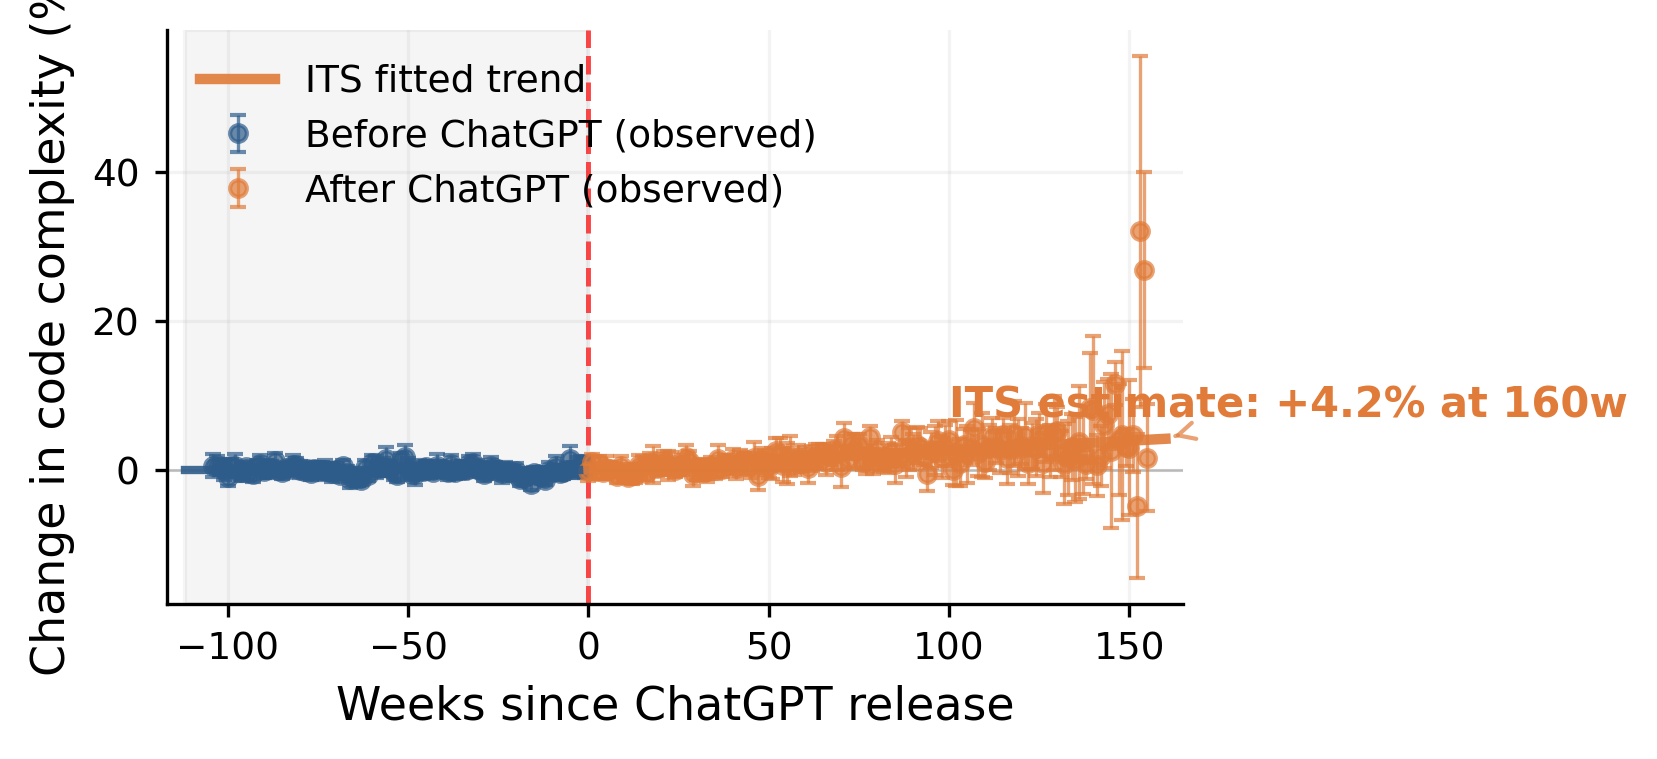

NameError: name 'PALETTE' is not defined

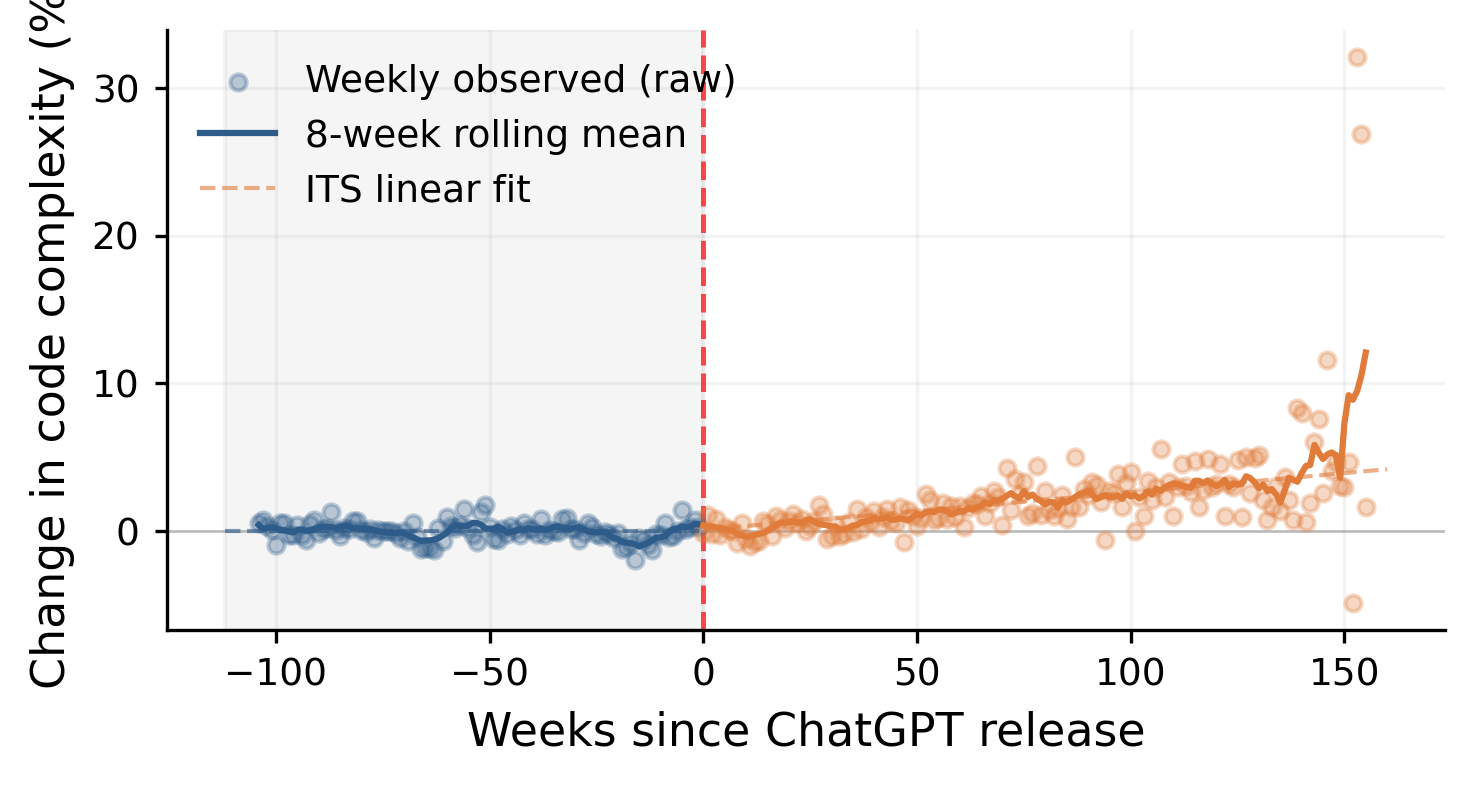

In [10]:
# ═══════════════════════════════════════════
# ITS 시각화: 실제 데이터 기반 (residual-style)
# ───────────────────────────────────────────
# 각 주의 효과 = (관측 평균) - (반사실 예측값)
# = ITS 모형이 예측한 "GPT 없었다면"에서 얼마나 벗어났는가
# ═══════════════════════════════════════════
# 전제: 앞서 m (Pooled ITS 모형) 이 적합되어 있음
# ═══════════════════════════════════════════

import numpy as np
import pandas as pd

# ───── 1. 반사실 예측값 계산 ─────
# 반사실 = 모든 관측치에서 post=0, post_t=0으로 강제했을 때의 예측
cf_data = weekly.copy()
cf_data['post']   = 0
cf_data['post_t'] = 0
weekly['y_cf']    = m.predict(cf_data)        # counterfactual (GPT 없었다면)
weekly['y_fit']   = m.predict(weekly)         # factual fit (GPT 있는 실제 추정)
weekly['effect_obs_log'] = weekly[TARGET] - weekly['y_cf']   # 관측 - 반사실
weekly['effect_obs_pct'] = (np.exp(weekly['effect_obs_log']) - 1) * 100

# ───── 2. 주별 가중 평균으로 집계 ─────
def weighted_mean(g, col):
    return np.average(g[col], weights=g['n_func'])
def weighted_sem(g, col):
    """가중 표준오차"""
    w = g['n_func']
    mu = np.average(g[col], weights=w)
    var = np.average((g[col] - mu)**2, weights=w)
    return np.sqrt(var / len(g)) if len(g) > 1 else np.nan

t_agg = weekly.groupby('t').apply(
    lambda g: pd.Series({
        'effect_pct':  weighted_mean(g, 'effect_obs_pct'),
        'sem':         weighted_sem(g, 'effect_obs_pct'),
        'n_lang':      g['language'].nunique(),
    })
).reset_index()

t_agg['ci_low']  = t_agg['effect_pct'] - 1.96 * t_agg['sem']
t_agg['ci_high'] = t_agg['effect_pct'] + 1.96 * t_agg['sem']

# ───── 3. 모형 예측 곡선 (덧그리기용) ─────
def its_effect_line(model, t_grid):
    β_p, β_pt = model.params['post'], model.params['post_t']
    eff = np.where(t_grid >= 0, β_p + β_pt * t_grid, 0.0)
    return (np.exp(eff) - 1) * 100

t_smooth = np.arange(MIN_WEEK, MAX_WEEK+1)
fit_pct  = its_effect_line(m, t_smooth)

# ═══════════════════════════════════════════
# 4. 시각화
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(5.5, 2.6), dpi=300)   # double column ~ wide

COLOR_PRE  = '#2E5C8A'
COLOR_POST = '#E07B39'

# 배경
ax.axvspan(MIN_WEEK, 0, alpha=0.08, color='gray', zorder=0)
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.axvline(0, color='red', ls='--', lw=1.2, alpha=0.7)

# ─── Pre 데이터 (실제 잔차) ───
pre = t_agg[t_agg['t'] < 0]
ax.errorbar(pre['t'], pre['effect_pct'],
            yerr=1.96*pre['sem'],
            fmt='o', color=COLOR_PRE, markersize=4,
            capsize=2, lw=0.8, alpha=0.7,
            label='Before ChatGPT (observed)')

# ─── Post 데이터 (실제 효과) ───
post = t_agg[t_agg['t'] >= 0]
ax.errorbar(post['t'], post['effect_pct'],
            yerr=1.96*post['sem'],
            fmt='o', color=COLOR_POST, markersize=4,
            capsize=2, lw=0.8, alpha=0.7,
            label='After ChatGPT (observed)')

# ─── ITS 모형 적합선 (덧그리기) ───
ax.plot(t_smooth[t_smooth < 0],  fit_pct[t_smooth < 0],
        '-', color=COLOR_PRE, lw=2, alpha=0.9, zorder=5)
ax.plot(t_smooth[t_smooth >= 0], fit_pct[t_smooth >= 0],
        '-', color=COLOR_POST, lw=2.5, alpha=0.9, zorder=5,
        label='ITS fitted trend')

# ─── 최종 효과 어노테이션 ───
final_pct = fit_pct[-1]
ax.annotate(
    f'ITS estimate: {final_pct:+.1f}% at {MAX_WEEK}w',
    xy=(MAX_WEEK, final_pct),
    xytext=(MAX_WEEK - 60, final_pct + 3),
    fontsize=10, color=COLOR_POST, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLOR_POST, lw=1, alpha=0.7),
)

# 스타일
ax.set_xlabel('Weeks since ChatGPT release', fontsize=11)
ax.set_ylabel('Change in code complexity (%)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.grid(alpha=0.15, zorder=0)
ax.set_xlim(MIN_WEEK - 5, MAX_WEEK + 5)

plt.tight_layout()
plt.savefig('its_observed.png', dpi=200, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════
# (선택) 추가: rolling mean smoothing으로 추세 보기
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(5.5, 2.6), dpi=300)   # double column ~ wide

# 배경
ax.axvspan(MIN_WEEK, 0, alpha=0.08, color='gray', zorder=0)
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.axvline(0, color='red', ls='--', lw=1.2, alpha=0.7)

# Rolling mean (8주 윈도우)
t_agg_sorted = t_agg.sort_values('t').reset_index(drop=True)
t_agg_sorted['effect_smooth'] = t_agg_sorted['effect_pct'].rolling(
    window=8, center=True, min_periods=3).mean()

# 점: 옅게 (raw)
pre  = t_agg_sorted[t_agg_sorted['t'] < 0]
post = t_agg_sorted[t_agg_sorted['t'] >= 0]
ax.scatter(pre['t'],  pre['effect_pct'],  s=15, color=COLOR_PRE,
           alpha=0.3, zorder=2, label='Weekly observed (raw)')
ax.scatter(post['t'], post['effect_pct'], s=15, color=COLOR_POST,
           alpha=0.3, zorder=2)

# Rolling line: 진하게
ax.plot(pre['t'],  pre['effect_smooth'],
        '-', color=COLOR_PRE, lw=1.5,
        label='8-week rolling mean')
ax.plot(post['t'], post['effect_smooth'],
        '-', color=COLOR_POST, lw=1.5)

# ITS 적합선 (점선으로 덧그리기)
ax.plot(t_smooth[t_smooth < 0],  fit_pct[t_smooth < 0],
        '--', color=COLOR_PRE, lw=1, alpha=0.6, zorder=4)
ax.plot(t_smooth[t_smooth >= 0], fit_pct[t_smooth >= 0],
        '--', color=COLOR_POST, lw=1, alpha=0.6, zorder=4,
        label='ITS linear fit')

ax.set_xlabel('Weeks since ChatGPT release', fontsize=11)
ax.set_ylabel('Change in code complexity (%)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.grid(alpha=0.15)
# 이벤트 점선
ax.axvline(0, color=PALETTE['event'], lw=0.8, ls='--', zorder=1)

# 마지막 포인트 annotation
# if HIGHLIGHT_LAST:
#     xl, yl = x[-1], y[-1]
#     # 마지막 점만 강조
#     ax.plot(xl, yl, marker='o', markersize=5,
#             markerfacecolor=PALETTE['event'],
#             markeredgecolor='white', markeredgewidth=0.8, zorder=5)
#     ax.annotate(f'+{yl:.1f}% at {int(xl)} weeks',
#                 xy=(xl, yl), xytext=(xl-30, yl+5),
#                 fontsize=8, color=PALETTE['event'], ha='right',
#                 arrowprops=dict(arrowstyle='-', color=PALETTE['event'],
#                                 lw=0.6, shrinkA=2, shrinkB=4))

# Spine 정리
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_position(('outward', 3))
ax.spines['bottom'].set_position(('outward', 3))

ax.set_xlabel(XLABEL)
ax.set_ylabel(YLABEL)
ax.set_xlim(x.min(), x.max())

# 격자 제거
ax.grid(False)

# 범례 — plot 영역 안 좌상단
ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98),
          handlelength=1.6, borderpad=0.4)

plt.tight_layout()
# plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig(OUT_PDF,           bbox_inches='tight', facecolor='white')
plt.show()

plt.tight_layout()
plt.savefig('its_observed_smooth.png', dpi=200, bbox_inches='tight')
plt.show()

print("="*60)
print("두 그림 비교")
print("="*60)
print("ITS 적합선 — 모형이 추정한 평균 효과 (직선)")
print("실제 데이터 — 주별로 출렁이는 raw 효과")
print(f"\n160주 시점 ITS 추정: {final_pct:+.2f}%")
print(f"160주 시점 실제 관측: {post['effect_pct'].iloc[-1]:+.2f}%")
print(f"마지막 8주 평균:      {post['effect_pct'].tail(8).mean():+.2f}%")

Compare Three types of SE
  Term                  SE Type         β       SE    z/t      p Sig
     t    Cluster (by language)  0.000036 0.000026  1.397 0.1624    
     t HAC (Newey-West, 8 lags)  0.000036 0.000024  1.543 0.1229    
     t    Driscoll-Kraay (BW=8)  0.000036 0.000030  1.217 0.2239    
  post    Cluster (by language) -0.000725 0.003023 -0.240 0.8106    
  post HAC (Newey-West, 8 lags) -0.000725 0.002286 -0.317 0.7513    
  post    Driscoll-Kraay (BW=8) -0.000725 0.002458 -0.295 0.7682    
post_t    Cluster (by language)  0.000301 0.000052  5.803 0.0000 ***
post_t HAC (Newey-West, 8 lags)  0.000301 0.000043  7.002 0.0000 ***
post_t    Driscoll-Kraay (BW=8)  0.000301 0.000041  7.348 0.0000 ***

핵심 계수 효과 크기 (모든 SE에서 β는 동일)
  Pre-trend      : β = +0.000036  →  +0.0036%
  Level change   : β = -0.000725  →  -0.0724%
  Slope change   : β = +0.000301  →  +0.0301%


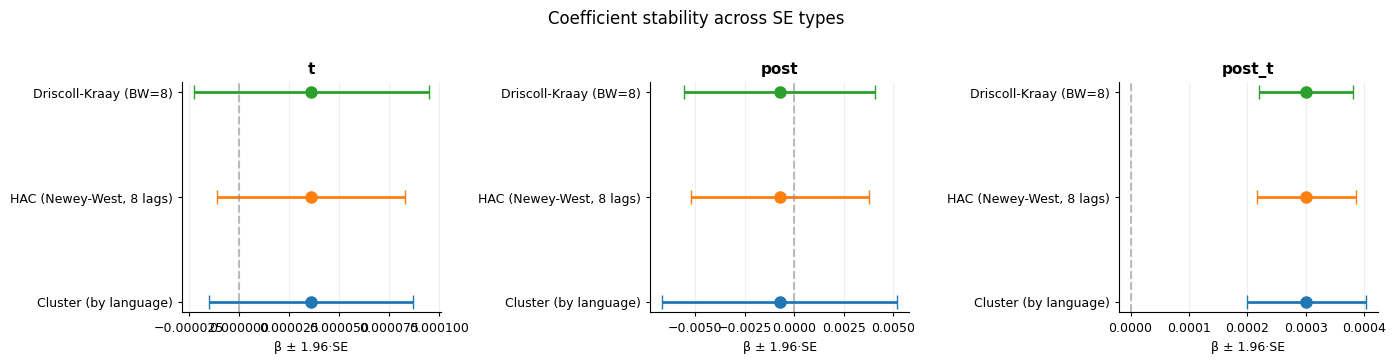

In [11]:
# ═══════════════════════════════════════════
# ITS: 세 가지 표준오차 비교
# (1) Cluster by language
# (2) HAC (Newey-West)
# (3) Driscoll-Kraay (kernel-based panel)
# ═══════════════════════════════════════════
# 사전 설치: pip install linearmodels
# ═══════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

# ───── 설정 ─────
TARGET  = 'log_cc_mean'
FORMULA = f'{TARGET} ~ t + post + post_t + C(language)'

# 정렬 (HAC는 시간순 정렬 필수)
weekly_sorted = weekly.sort_values(['language', 't']).reset_index(drop=True)

# ═══════════════════════════════════════════
# (1) Cluster SE (by language)
# ═══════════════════════════════════════════
m_cluster = smf.wls(
    FORMULA, data=weekly_sorted, weights=weekly_sorted['n_func']
).fit(
    cov_type='cluster',
    cov_kwds={'groups': weekly_sorted['language']}
)

# ═══════════════════════════════════════════
# (2) HAC SE (Newey-West)
# ═══════════════════════════════════════════
m_hac = smf.wls(
    FORMULA, data=weekly_sorted, weights=weekly_sorted['n_func']
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 8}
)

# ═══════════════════════════════════════════
# (3) Driscoll-Kraay SE (via linearmodels)
# ═══════════════════════════════════════════
# linearmodels는 (entity, time) multi-index 필요
panel_data = weekly_sorted.set_index(['language', 'week']).copy()

# PanelOLS: 언어 고정효과는 EntityEffects로 자동 처리
mod_dk = PanelOLS.from_formula(
    f'{TARGET} ~ 1 + t + post + post_t + EntityEffects',
    data=panel_data,
    weights=panel_data['n_func']
)
m_dk = mod_dk.fit(
    cov_type='kernel',       # kernel = Driscoll-Kraay
    kernel='bartlett',       # Newey-West와 동일 커널
    bandwidth=8              # HAC와 같은 lag로 비교
)

# ═══════════════════════════════════════════
# 결과 비교표
# ═══════════════════════════════════════════
def extract_coef(model, term, is_panel=False):
    """statsmodels와 linearmodels 모두에서 계수/SE/p 추출"""
    if is_panel:
        β  = model.params[term]
        se = model.std_errors[term]
        p  = model.pvalues[term]
    else:
        β  = model.params[term]
        se = model.bse[term]
        p  = model.pvalues[term]
    return β, se, p

rows = []
for term in ['t', 'post', 'post_t']:
    for m, lab, panel in [
        (m_cluster, 'Cluster (by language)', False),
        (m_hac,     'HAC (Newey-West, 8 lags)', False),
        (m_dk,      'Driscoll-Kraay (BW=8)', True),
    ]:
        β, se, p = extract_coef(m, term, panel)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        rows.append({
            'Term':    term,
            'SE Type': lab,
            'β':       round(β, 6),
            'SE':      round(se, 6),
            'z/t':     round(β/se, 3) if se>0 else np.nan,
            'p':       round(p, 4),
            'Sig':     sig,
        })

comp = pd.DataFrame(rows)
print("="*70)
print("Compare Three types of SE")
print("="*70)
print(comp.to_string(index=False))

# ═══════════════════════════════════════════
# 효과 크기 환산 (% 단위)
# ═══════════════════════════════════════════
print("\n" + "="*70)
print("핵심 계수 효과 크기 (모든 SE에서 β는 동일)")
print("="*70)
for term, label in [('t',      'Pre-trend'),
                    ('post',   'Level change'),
                    ('post_t', 'Slope change')]:
    β = m_cluster.params[term]
    pct = (np.exp(β) - 1) * 100
    print(f"  {label:15s}: β = {β:+.6f}  →  {pct:+.4f}%")

# ═══════════════════════════════════════════
# 시각화: SE 비교 (forest plot 스타일)
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)

colors = {'Cluster (by language)':    '#1f77b4',
          'HAC (Newey-West, 8 lags)': '#ff7f0e',
          'Driscoll-Kraay (BW=8)':    '#2ca02c'}

for ax, term in zip(axes, ['t', 'post', 'post_t']):
    sub = comp[comp['Term'] == term].reset_index(drop=True)
    y_pos = np.arange(len(sub))

    for i, row in sub.iterrows():
        ax.errorbar(
            row['β'], i,
            xerr=1.96 * row['SE'],
            fmt='o', color=colors[row['SE Type']],
            markersize=8, capsize=5, lw=2,
        )

    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['SE Type'], fontsize=9)
    ax.set_title(f'{term}', fontsize=11, fontweight='bold')
    ax.set_xlabel('β ± 1.96·SE', fontsize=9)
    ax.grid(alpha=0.2, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Coefficient stability across SE types', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('se_comparison.png', dpi=200, bbox_inches='tight')
plt.show()